<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/ModernNCA_TONIoT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# ModernNCA settings
DEVICE     = "cuda"
N_EPOCHS   = 100
BATCH_SIZE = 512
LR         = 1e-3
D_MODEL    = 128
N_LAYERS   = 4
DROPOUT    = 0.1
SNS_RATIO  = 0.1
PATIENCE   = 15        # early stopping patience

print("Config loaded.")

Config loaded.


In [2]:
#Install Libraries

!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed.")

All packages installed.


In [3]:
# IMPORTS + DRIVE MOUNT + GPU CHECK

import os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# GPU check
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. ModernNCA will run on CPU (slower).")
    print("Go to Runtime- Change runtime type - T4 GPU - Save")
    DEVICE = "cpu"
else:
    print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Device        : {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU confirmed : Tesla T4
VRAM          : 15.6 GB
Device        : cuda


In [4]:
#Loading data

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows   : {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows   : 211,043
Total columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
#PREPROCESS

# Drop label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keep numeric features only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features     : {X.shape[1]}")

# 70 / 10 / 20
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv
)
print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute NaN using TRAIN median only (no data leakage)
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale using TRAIN statistics only (no data leakage)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features     : 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [6]:
#EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

print("Evaluation helper ready.")

Evaluation helper ready.


In [7]:
# ModernNCA MODEL DEFINITION


class ModernNCAEncoder(nn.Module):
    """Deep encoder for ModernNCA: maps raw features to embedding space."""

    def __init__(self, n_features, d_model=128, n_layers=4, dropout=0.1):
        super().__init__()
        layers = []
        in_dim = n_features
        for i in range(n_layers):
            out_dim = d_model
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = out_dim
        # Final projection (no activation — raw embedding)
        layers.append(nn.Linear(in_dim, d_model))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)


class ModernNCA:

    def __init__(self, n_features, num_classes, d_model=128, n_layers=4,
                 dropout=0.1, sns_ratio=0.1, device="cuda"):
        self.device = device
        self.num_classes = num_classes
        self.sns_ratio = sns_ratio

        self.encoder = ModernNCAEncoder(
            n_features, d_model, n_layers, dropout
        ).to(device)

        self.optimizer = torch.optim.AdamW(
            self.encoder.parameters(), lr=LR, weight_decay=1e-5
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=N_EPOCHS
        )

        # Store training data for inference
        self._train_embeddings = None
        self._train_labels = None

    def _nca_loss(self, embeddings, labels):

        batch_size = embeddings.size(0)

        # SNS: sample a subset of the batch as neighbors
        sns_size = max(int(batch_size * self.sns_ratio), 32)
        sns_size = min(sns_size, batch_size)
        sns_idx = torch.randperm(batch_size, device=self.device)[:sns_size]
        neighbors = embeddings[sns_idx]        # (sns_size, d)
        neighbor_labels = labels[sns_idx]      # (sns_size,)

        # Pairwise squared distances: (batch, sns_size)
        dists = torch.cdist(embeddings, neighbors, p=2).pow(2)

        # Softmax weights (exclude self if present)
        # Use temperature scaling for numerical stability
        weights = F.softmax(-dists, dim=1)     # (batch, sns_size)

        # Mask: same class
        same_class = (labels.unsqueeze(1) == neighbor_labels.unsqueeze(0)).float()

        # Probability of correct classification for each sample
        p_correct = (weights * same_class).sum(dim=1)

        # NCA loss: negative log probability
        loss = -torch.log(p_correct + 1e-8).mean()
        return loss

    def fit(self, X_train, y_train, X_val, y_val, n_epochs=100,
            batch_size=512, patience=15):

        train_ds = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long)
        )
        train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(self.device)
        y_val_t = torch.tensor(y_val, dtype=torch.long).to(self.device)

        best_val_f1 = 0
        best_state  = None
        no_improve  = 0

        for epoch in range(1, n_epochs + 1):
            self.encoder.train()
            epoch_loss = 0
            for xb, yb in train_dl:
                xb, yb = xb.to(self.device), yb.to(self.device)
                self.optimizer.zero_grad()
                emb = self.encoder(xb)
                loss = self._nca_loss(emb, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.encoder.parameters(), 1.0)
                self.optimizer.step()
                epoch_loss += loss.item()

            self.scheduler.step()

            # Validation
            val_preds = self._predict_from_tensor(X_val_t, X_train, y_train)
            val_acc = accuracy_score(y_val, val_preds)
            val_f1  = f1_score(y_val, val_preds, average="macro", zero_division=0)

            avg_loss = epoch_loss / len(train_dl)
            print(f"  Epoch {epoch:03d}/{n_epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_state = {k: v.cpu().clone() for k, v in
                              self.encoder.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch} "
                      f"(best Val F1: {best_val_f1:.4f})")
                break

        # Restore best weights
        self.encoder.load_state_dict(
            {k: v.to(self.device) for k, v in best_state.items()}
        )
        self.encoder.eval()

        # Cache training embeddings for inference
        self._cache_train_embeddings(X_train, y_train)
        print(f"\nBest Val F1: {best_val_f1:.4f}")

    def _cache_train_embeddings(self, X_train, y_train):
        """Pre-compute and store training embeddings for inference."""
        self.encoder.eval()
        X_t = torch.tensor(X_train, dtype=torch.float32)
        ds = TensorDataset(X_t)
        dl = DataLoader(ds, batch_size=2048, shuffle=False)
        embs = []
        with torch.no_grad():
            for (xb,) in dl:
                embs.append(self.encoder(xb.to(self.device)).cpu())
        self._train_embeddings = torch.cat(embs, dim=0).to(self.device)
        self._train_labels = torch.tensor(y_train, dtype=torch.long).to(self.device)

    def _predict_from_tensor(self, X_test_t, X_train_np, y_train_np, k=64):
        """Predict using distance-weighted k-NN in embedding space."""
        self.encoder.eval()

        # Encode training data (use cached if available)
        if self._train_embeddings is not None:
            train_emb = self._train_embeddings
            train_y   = self._train_labels
        else:
            with torch.no_grad():
                chunks = []
                for i in range(0, len(X_train_np), 2048):
                    xb = torch.tensor(
                        X_train_np[i:i+2048], dtype=torch.float32
                    ).to(self.device)
                    chunks.append(self.encoder(xb))
                train_emb = torch.cat(chunks, dim=0)
            train_y = torch.tensor(y_train_np, dtype=torch.long).to(self.device)

        all_preds = []
        with torch.no_grad():
            for i in range(0, len(X_test_t), 2048):
                xb = X_test_t[i:i+2048]
                if xb.device != self.device:
                    xb = xb.to(self.device)
                test_emb = self.encoder(xb)

                # k-NN: find k closest training embeddings
                dists = torch.cdist(test_emb, train_emb, p=2)
                topk_dists, topk_idx = dists.topk(k, largest=False)

                # Distance-weighted voting
                weights = F.softmax(-topk_dists, dim=1)  # (batch, k)
                neighbor_labels = train_y[topk_idx]       # (batch, k)

                # Accumulate votes per class
                votes = torch.zeros(
                    xb.size(0), self.num_classes, device=self.device
                )
                votes.scatter_add_(1, neighbor_labels, weights)
                preds = votes.argmax(dim=1).cpu().numpy()
                all_preds.append(preds)

        return np.concatenate(all_preds)

    def predict(self, X_test_np, X_train_np=None, y_train_np=None, k=64):
        """Predict labels for test data."""
        X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(self.device)
        X_tr = X_train_np if X_train_np is not None else None
        y_tr = y_train_np if y_train_np is not None else None
        return self._predict_from_tensor(X_test_t, X_tr, y_tr, k=k)

params = sum(p.numel() for p in
             ModernNCAEncoder(n_features, D_MODEL, N_LAYERS, DROPOUT).parameters())
print(f"ModernNCA encoder params: {params:,}")
print("Model class ready.")

ModernNCA encoder params: 69,376
Model class ready.


In [8]:
# ModernNCA TRAINING

model = ModernNCA(
    n_features=n_features,
    num_classes=num_classes,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    sns_ratio=SNS_RATIO,
    device=DEVICE,
)

print("Training ModernNCA on TON-IoT...")
print(f"Config: d_model={D_MODEL}, n_layers={N_LAYERS}, "
      f"sns_ratio={SNS_RATIO}, lr={LR}, epochs={N_EPOCHS}")
print()

t0 = time.time()

model.fit(
    X_train_s, y_train,
    X_val_s,   y_val,
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
)

train_time = time.time() - t0
print(f"\nModernNCA training complete in {train_time:.1f}s ({train_time/60:.1f} min)")

Training ModernNCA on TON-IoT...
Config: d_model=128, n_layers=4, sns_ratio=0.1, lr=0.001, epochs=100

  Epoch 001/100 | Loss: 1.3613 | Val Acc: 0.9294 | Val F1: 0.8436
  Epoch 002/100 | Loss: 1.0802 | Val Acc: 0.9397 | Val F1: 0.8603
  Epoch 003/100 | Loss: 0.9904 | Val Acc: 0.9301 | Val F1: 0.8414
  Epoch 004/100 | Loss: 0.9181 | Val Acc: 0.9494 | Val F1: 0.8846
  Epoch 005/100 | Loss: 0.8512 | Val Acc: 0.9512 | Val F1: 0.8907
  Epoch 006/100 | Loss: 0.8562 | Val Acc: 0.9491 | Val F1: 0.8858
  Epoch 007/100 | Loss: 0.8024 | Val Acc: 0.9405 | Val F1: 0.8662
  Epoch 008/100 | Loss: 0.7756 | Val Acc: 0.9455 | Val F1: 0.8861
  Epoch 009/100 | Loss: 0.7460 | Val Acc: 0.9517 | Val F1: 0.8827
  Epoch 010/100 | Loss: 0.7111 | Val Acc: 0.9486 | Val F1: 0.8852
  Epoch 011/100 | Loss: 0.7348 | Val Acc: 0.9407 | Val F1: 0.8728
  Epoch 012/100 | Loss: 0.7116 | Val Acc: 0.9444 | Val F1: 0.8796
  Epoch 013/100 | Loss: 0.6874 | Val Acc: 0.9417 | Val F1: 0.8750
  Epoch 014/100 | Loss: 0.6788 | Val Ac

Inference time : 1.94s for 42,209 samples
                (0.0460 ms per sample)

  ModernNCA — Results
  Accuracy      : 0.9647
  F1 (macro)    : 0.9138
  F1 (weighted) : 0.9645

              precision    recall  f1-score   support

    backdoor       0.99      1.00      0.99      4000
        ddos       0.96      0.95      0.95      4000
         dos       0.99      0.97      0.98      4000
   injection       0.95      0.90      0.92      4000
        mitm       0.61      0.40      0.49       209
      normal       1.00      1.00      1.00     10000
    password       0.95      0.95      0.95      4000
  ransomware       0.98      1.00      0.99      4000
    scanning       0.98      0.94      0.96      4000
         xss       0.86      0.95      0.90      4000

    accuracy                           0.96     42209
   macro avg       0.93      0.91      0.91     42209
weighted avg       0.97      0.96      0.96     42209



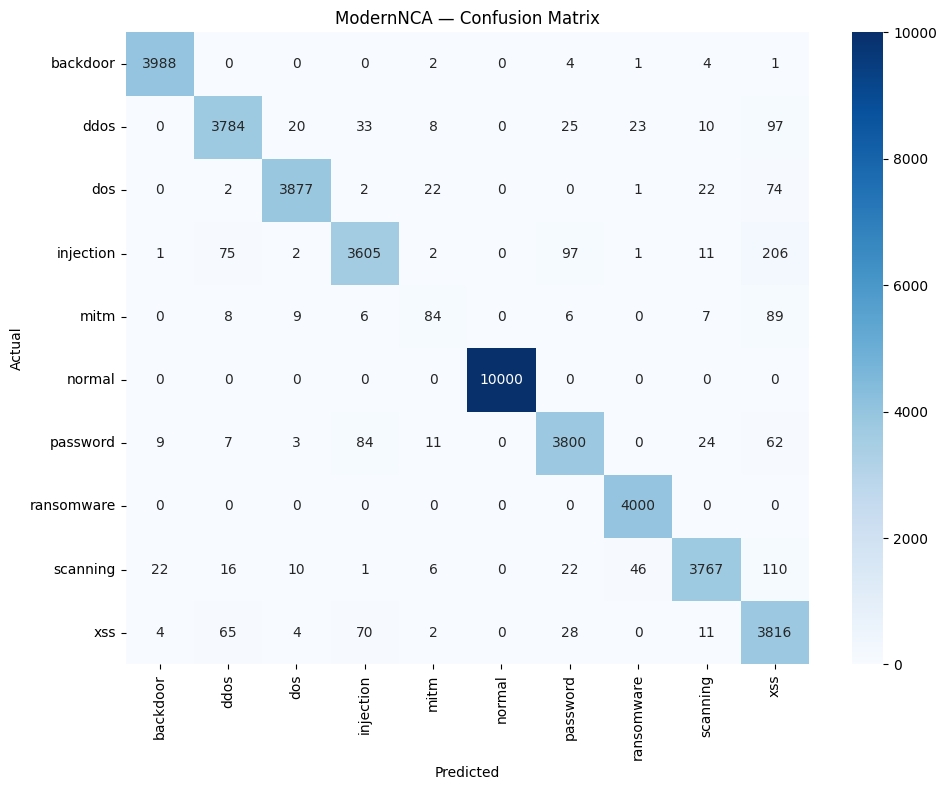

Saved: /content/drive/MyDrive/toniot_outputs/modernnca_cm.png


In [9]:
# ModernNCA TEST EVALUATION

t0 = time.time()
modernnca_preds = model.predict(X_test_s)
infer_time = time.time() - t0

print(f"Inference time : {infer_time:.2f}s for {len(X_test_s):,} samples")
print(f"                ({infer_time / len(X_test_s) * 1000:.4f} ms per sample)")

modernnca_results = evaluate(
    "ModernNCA", y_test, modernnca_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

In [11]:
#OVERFITTING / UNDERFITTING

modernnca_train_preds = model.predict(X_train_s)
modernnca_train_acc   = accuracy_score(y_train, modernnca_train_preds)
modernnca_train_f1    = f1_score(y_train, modernnca_train_preds, average="macro", zero_division=0)

print("=" * 50)
print("ModernNCA — Train vs Test Diagnosis")
print("=" * 50)
print(f"  Train Acc    : {modernnca_train_acc:.4f}")
print(f"  Test  Acc    : {modernnca_results['accuracy']:.4f}")
print(f"  Train F1     : {modernnca_train_f1:.4f}")
print(f"  Test  F1     : {modernnca_results['f1_macro']:.4f}")
print()

acc_gap = modernnca_train_acc - modernnca_results['accuracy']
if acc_gap > 0.05:
    print(f"  Warning: Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif modernnca_results['accuracy'] < 0.80:
    print("  Warning: Low test accuracy — possible underfitting")
else:
    print(f"  Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {train_time:.1f}s")
print(f"  Inference time: {infer_time:.2f}s ({len(X_test_s):,} samples)")

ModernNCA — Train vs Test Diagnosis
  Train Acc    : 0.9658
  Test  Acc    : 0.9647
  Train F1     : 0.9148
  Test  F1     : 0.9138

  Generalisation gap: 0.0011 — model generalises well

  Training time : 216.3s
  Inference time: 1.94s (42,209 samples)


In [12]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"        : "ModernNCA",
    "paper"        : "ICLR 2025 — Ye et al.",
    "dataset"      : "TON-IoT Network",
    "train_samples": len(X_train),
    "test_samples" : len(X_test_s),
    "n_features"   : n_features,
    "n_classes"    : num_classes,
    "accuracy"     : modernnca_results["accuracy"],
    "f1_macro"     : modernnca_results["f1_macro"],
    "f1_weighted"  : modernnca_results["f1_weighted"],
    "train_acc"    : modernnca_train_acc,
    "train_f1"     : modernnca_train_f1,
    "train_time_s" : round(train_time, 2),
    "infer_time_s" : round(infer_time, 4),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "modernnca_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                   0
model                      ModernNCA
paper          ICLR 2025 — Ye et al.
dataset              TON-IoT Network
train_samples                 147729
test_samples                   42209
n_features                        17
n_classes                         10
accuracy                    0.964747
f1_macro                    0.913824
f1_weighted                 0.964539
train_acc                   0.965816
train_f1                    0.914781
train_time_s                  216.26
infer_time_s                  1.9407

Results saved to: /content/drive/MyDrive/toniot_outputs/modernnca_toniot_results.csv
